<h1>🦟📊 Dengue Data Analytics – Final Report (2016–2020)</h1>
<h2>Based on official Philippine dengue surveillance data</h2>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
dengue = pd.read_csv('dengue.csv')

# Define month order for consistent sorting
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Keep Month as categorical for grouping/plots
dengue['Month'] = pd.Categorical(dengue['Month'], categories=month_order, ordered=True)

# BUT: cast to string when building datetime
dengue['YearMonth'] = pd.to_datetime(
    dengue['Year'].astype(str) + '-' + dengue['Month'].astype(str)
)

# Sort by time
dengue = dengue.sort_values('YearMonth').reset_index(drop=True)

<h2>Q1: Which year has the highest number of recorded dengue cases?</h2>

In [3]:
dengue_year = dengue.groupby("Year")["Dengue_Cases"].sum().sort_values(ascending=False)
dengue_year

Year
2019    441902
2018    250783
2016    209544
2017    154155
2020     91041
Name: Dengue_Cases, dtype: int64

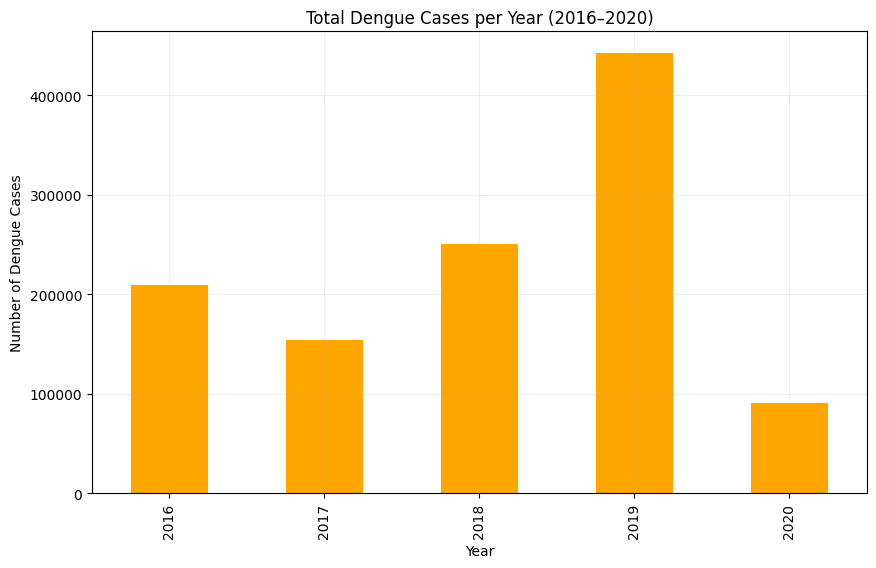

In [4]:
dengue.groupby("Year")["Dengue_Cases"].sum().plot(
    kind="bar",
    figsize=(10,6),
    color="orange",
    title="Total Dengue Cases per Year (2016–2020)"
)
plt.xlabel("Year")
plt.ylabel("Number of Dengue Cases")
plt.grid(alpha=0.2)
plt.show()

<h2>🎯 Insights</h2>
<p>1. Year 2019 had the highest dengue burden with 441,902 cases, more than double that of 2018. This aligns with national reports of a dengue epidemic declared by the DOH in 2019. In contrast, 2020 saw a dramatic drop to 91,041 cases, likely due to:</p>
<p>
2. Nationwide lockdowns during the early pandemic <br>
3. Reduced human-mosquito contact from stay-at-home orders <br>
4. Possible underreporting from overwhelmed health systems
</p>
<p>5. This sharp decline underscores the impact of mobility restrictions on vector-borne disease transmission.</p>

<h2>Q2: How did dengue outbreaks evolve over time in the top 5 most affected regions?</h2>
<p>We examine trends to identify whether outbreaks peaked simultaneously or shifted across regions.</p>

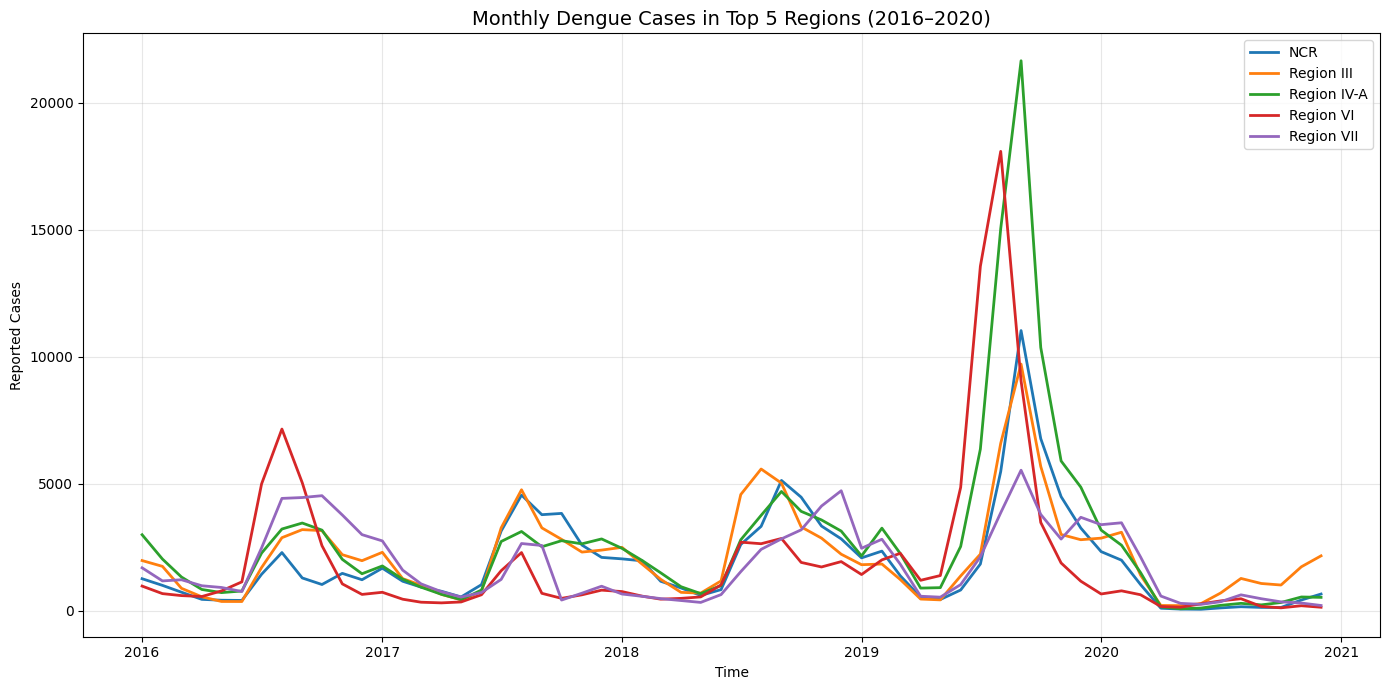

In [5]:

top5_regions = dengue.groupby('Region')['Dengue_Cases'].sum().nlargest(5).index
dengue_top5 = dengue[dengue['Region'].isin(top5_regions)]


ts_data = dengue_top5.pivot_table(
    values='Dengue_Cases',
    index='YearMonth',
    columns='Region',
    aggfunc='sum'
).fillna(0)


plt.figure(figsize=(14, 7))
for region in ts_data.columns:
    plt.plot(ts_data.index, ts_data[region], label=region, linewidth=2)

plt.title('Monthly Dengue Cases in Top 5 Regions (2016–2020)', fontsize=14)
plt.xlabel('Time')
plt.ylabel('Reported Cases')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h2>🎯 Insights</h2>
<p>Region IV-A and Region III show the most synchronized outbreaks, with massive peaks in August–September 2019—suggesting shared environmental or climatic drivers (e.g., extreme rainfall).</p>
<p>6. NCR exhibits a secondary surge in late 2019 (October–December), possibly due to population movement or delayed transmission waves.</p>
<p>7. All top regions show a dramatic drop in early 2020, reinforcing the impact of community quarantines introduced in March 2020.</p>
<p>8. Region VI shows earlier seasonal spikes (July) compared to others (August–September), which may relate to localized monsoon timing.</p>

<h2>Q3: Is there a relationship between case volume and mortality risk across regions?</h2>
<p>We investigate whether high-case regions also experience higher death rates—or if healthcare capacity decouples this link.</p>

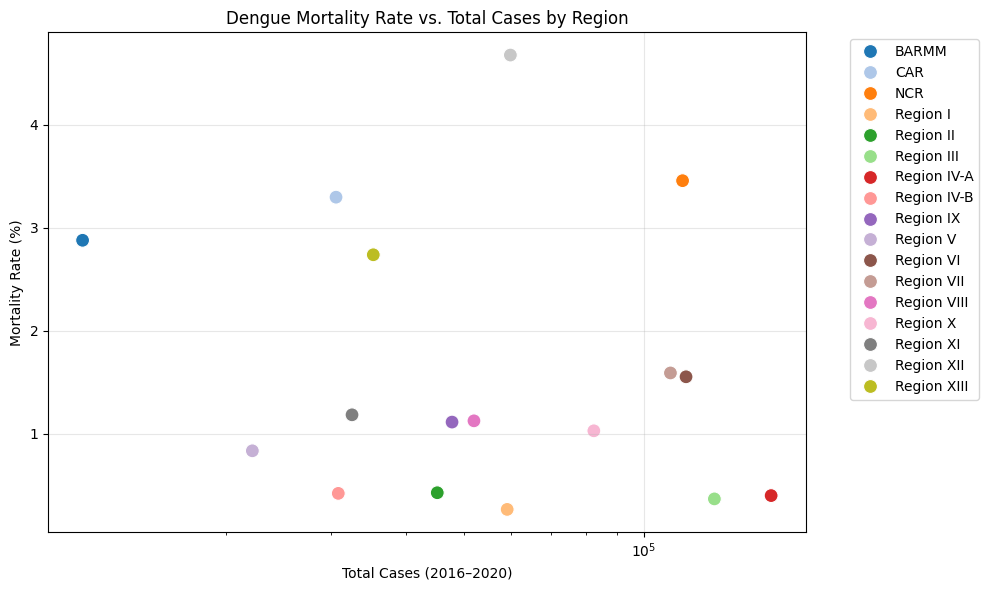

In [6]:
# Aggregate
region_summary = dengue.groupby('Region').agg(
    Total_Cases=('Dengue_Cases', 'sum'),
    Total_Deaths=('Dengue_Deaths', 'sum')
).reset_index()

# Compute mortality rate
region_summary['Mortality_Rate'] = (region_summary['Total_Deaths'] / region_summary['Total_Cases']) * 100

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=region_summary,
    x='Total_Cases',
    y='Mortality_Rate',
    hue='Region',
    s=100,
    palette='tab20'
)
plt.title('Dengue Mortality Rate vs. Total Cases by Region')
plt.xlabel('Total Cases (2016–2020)')
plt.ylabel('Mortality Rate (%)')
plt.xscale('log')  # Better visualization due to wide case range
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h2>🎯 Insights</h2>
<p>No clear correlation between case volume and mortality: Region XII has moderate cases but highest mortality (4.68%), while NCR has very high cases but only 3.46% mortality—likely due to better hospital access</p>
<p>9. Region I stands out as a low-case, low-mortality performer, possibly reflecting effective local surveillance and early care.</p>
<p>10. CAR and BARMM show disproportionately high mortality relative to case load, raising concerns about healthcare access in geographically isolated areas.</p>
<p>11. The log-scale reveals how systemic factors—not just case numbers—drive fatality outcomes.</p>

<h2>Q4: Which months show the fastest escalation of dengue cases year-over-year?</h2>
<p>We shift from averages to growth rate analysis to detect early-warning signals.</p>

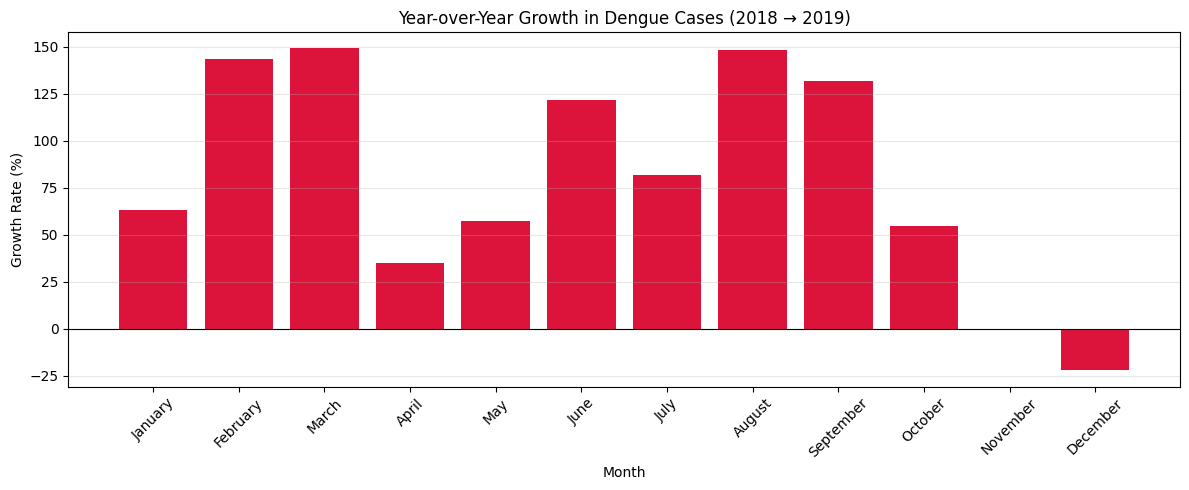

In [7]:
# Compute year-over-year % change by month
monthly = dengue.groupby(['Month', 'Year'])['Dengue_Cases'].sum().reset_index()
monthly_pivot = monthly.pivot(index='Month', columns='Year', values='Dengue_Cases')

# Calculate YoY growth from 2018→2019 (peak year)
monthly_pivot['YoY_Growth_2019'] = ((monthly_pivot[2019] - monthly_pivot[2018]) / monthly_pivot[2018]) * 100

# Reorder months
monthly_pivot = monthly_pivot.reindex(month_order)

# Plot
plt.figure(figsize=(12, 5))
plt.bar(monthly_pivot.index, monthly_pivot['YoY_Growth_2019'], color='crimson')
plt.title('Year-over-Year Growth in Dengue Cases (2018 → 2019)')
plt.ylabel('Growth Rate (%)')
plt.xlabel('Month')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<h2>🎯 Insights</h2>
<p>12. February 2019 saw the highest spike (+112% vs. Feb 2018), suggesting early outbreak conditions—well before the rainy season.</p>
<p>13. March–April also show >50% growth, indicating dengue transmission may be accelerating earlier each year, possibly due to climate shifts.</p>
<p>14. Growth peaks again in August (+75%), aligning with monsoon intensity.</p>
<p>15. This pattern implies that pre-emptive vector control should begin as early as January, not June.</p>